<div style="background: linear-gradient(135deg, #0d0221 0%, #1a0533 50%, #0f172a 100%); border-radius: 16px; padding: 40px 36px; margin-bottom: 8px; border: 1px solid #7c3aed55;">
  <h1 style="color:#c4b5fd; font-size:2.4rem; font-family:'Segoe UI',sans-serif; margin:0 0 8px 0;">🔐 Web Attack Detection</h1>
  <h2 style="color:#818cf8; font-size:1.3rem; font-weight:400; font-family:'Segoe UI',sans-serif; margin:0 0 18px 0;">End-to-End Machine Learning Pipeline</h2>
  <p style="color:#94a3b8; font-size:0.95rem; line-height:1.7; max-width:680px;">
    Dataset: <strong style="color:#a78bfa">shengqin/web-attacks-long</strong> (Hugging Face)<br>
    Classes: <span style="background:#7c3aed22; padding:2px 8px; border-radius:4px; color:#a78bfa">XSS</span>
    &nbsp;<span style="background:#06b6d422; padding:2px 8px; border-radius:4px; color:#67e8f9">SQLi</span>
    &nbsp;<span style="background:#10b98122; padding:2px 8px; border-radius:4px; color:#6ee7b7">Normal</span><br>
    Pipeline steps: Data Collection → Cleaning → Preprocessing → Split → Train → Evaluate → Tune → Predict → Deploy
  </p>
</div>

# **Student Name :** Dakshini Anand Neel
# **Student ID :** 2026CS001
# **Topic :** Cyber Security - Web Attack Detection

## 📋 Table of Contents

| Step | Section |
|------|------------------------|
| 0 | Setup & Imports |
| 1 | Data Collection |
| 2 | Data Cleaning |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Preprocessing |
| 5 | Train-Test Split |
| 6 | Model Training |
| 7 | Model Evaluation |
| 8 | Hyperparameter Tuning |
| 9 | Final Prediction |
| 10 | Deployment |

---
## ⚙️ Step 0 — Setup & Imports

In [56]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import json
import math
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Numerical / Data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Scikit-learn ──────────────────────────────────────────────────────────────
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                    MaxAbsScaler, Normalizer, LabelEncoder, label_binarize)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE, SelectFromModel
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)
from scipy.stats import entropy

# ── Project config ────────────────────────────────────────────────────────────
BASE_DIR   = Path(r"E:\CYBERSECURITY")
DATA_DIR   = BASE_DIR / "data"
MODEL_DIR  = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"
for d in (DATA_DIR, MODEL_DIR, REPORT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── Plot globals ──────────────────────────────────────────────────────────────
DARK_BG   = "#0d0221"
MID_BG    = "#1a0533"
ACCENT    = "#7c3aed"
PALETTE   = ["#7c3aed", "#06b6d4", "#10b981", "#f59e0b", "#ef4444", "#f97316", "#8b5cf6"]
CLASS_COLORS = {"XSS": "#7c3aed", "SQLi": "#06b6d4", "Normal": "#10b981"}

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor":   DARK_BG,
    "axes.edgecolor":   "#4b5563",
    "grid.color":       "#1f2937",
    "text.color":       "#f3f4f6",
    "axes.labelcolor":  "#f3f4f6",
    "xtick.color":      "#9ca3af",
    "ytick.color":      "#9ca3af",
    "font.size":        11,
})

DATASET_URL = "https://huggingface.co/datasets/shengqin/web-attacks-long/resolve/main/train.csv"

print("✅ All libraries loaded. Project base:", BASE_DIR)

✅ All libraries loaded. Project base: E:\CYBERSECURITY


---
## 📥 Step 1 — Data Collection

We load the **`shengqin/web-attacks-long`** dataset directly from Hugging Face.
The dataset contains web HTTP payloads labeled as **XSS**, **SQLi**, or **Normal**.

In [57]:
RAW_CSV = DATA_DIR / "raw_train.csv"

# ── Load ──────────────────────────────────────────────────────────────────────
if RAW_CSV.exists():
    print(f"📂 Loading from local cache: {RAW_CSV}")
    df_raw = pd.read_csv(RAW_CSV)
else:
    try:
        from datasets import load_dataset as hf_load
        print("🌐 Fetching via Hugging Face datasets library …")
        hf_ds  = hf_load("shengqin/web-attacks-long", split="train")
        df_raw = hf_ds.to_pandas()
    except Exception:
        print("🌐 Falling back to direct CSV URL …")
        df_raw = pd.read_csv(DATASET_URL)
    df_raw.to_csv(RAW_CSV, index=False)
    print(f"💾 Saved raw copy → {RAW_CSV}")

print(f"\n📊 Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("\nColumn dtypes:")
print(df_raw.dtypes)
print()
df_raw.head()

📂 Loading from local cache: E:\CYBERSECURITY/data/raw_train.csv

📊 Dataset shape: 18,400 rows × 4 columns

Column dtypes:
Payload       object
Label          int64
text_label    object
ID             int64
dtype: object



,Payload,Label,text_label,ID
0,Select a paint color for the room.,3,normal,24223
1,"1%"" ) ) ) union all select null,null,null#",2,SQLi,19275
2,<cite onpointerup=alert(1)>XSS</cite>,1,XSS,8703
3,"{""id"":null,""name"":""Slowbro""}",3,normal,27101
4,<style>:target {transform: rotate(180deg);}</s...,1,XSS,655


In [58]:
# ── Class distribution bar chart ──────────────────────────────────────────────
label_counts = df_raw["text_label"].value_counts()

fig = go.Figure(go.Bar(
    x=label_counts.index,
    y=label_counts.values,
    marker_color=[CLASS_COLORS.get(l, ACCENT) for l in label_counts.index],
    text=label_counts.values,
    textposition="outside",
))
fig.update_layout(
    title=dict(text="📊 Class Distribution in Dataset", font=dict(size=18, color="#c4b5fd")),
    paper_bgcolor=DARK_BG, plot_bgcolor=MID_BG,
    font=dict(color="#f3f4f6"),
    xaxis=dict(title="Attack Class"),
    yaxis=dict(title="Sample Count", gridcolor="#1f2937"),
    showlegend=False,
)
fig.show()

# Pie chart
fig2 = go.Figure(go.Pie(
    labels=label_counts.index,
    values=label_counts.values,
    marker_colors=[CLASS_COLORS.get(l, ACCENT) for l in label_counts.index],
    hole=0.45,
    textinfo="label+percent",
))
fig2.update_layout(
    title=dict(text="🥧 Class Proportion", font=dict(size=18, color="#c4b5fd")),
    paper_bgcolor=DARK_BG,
    font=dict(color="#f3f4f6"),
)
fig2.show()

In [59]:
# ── 3D View of Raw Data Distribution ────────────────────────────────────────
from sklearn.decomposition import PCA

# Local feature extraction to resolve previous NameError
def quick_features(text):
    text = str(text)
    # Count length, digits, and special characters correctly
    return [len(text), sum(c.isdigit() for c in text), sum(text.count(c) for c in '<>"\\()')]

# Create a temporary feature set for PCA
X_temp = np.array([quick_features(p) for p in df_raw['Payload']])

# Dimensionality reduction
pca_3d = PCA(n_components=3)
X_pca = pca_3d.fit_transform(X_temp)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['label'] = df_raw['text_label'].values

fig_3d = px.scatter_3d(
    pca_df, x='PC1', y='PC2', z='PC3', color='label',
    color_discrete_map=CLASS_COLORS, opacity=0.7,
    title="🌌 3D Feature Space Projection (PCA)",
    template="plotly_dark"
)
fig_3d.update_layout(
    scene=dict(
        xaxis_backgroundcolor=DARK_BG,
        yaxis_backgroundcolor=DARK_BG,
        zaxis_backgroundcolor=DARK_BG,
    ),
    paper_bgcolor=DARK_BG,
    font=dict(color="#f3f4f6")
)
fig_3d.show()

---
## 🧹 Step 2 — Data Cleaning

| Task | Action |
|------|--------|
| **Remove Duplicates** | Drop identical rows |
| **Handle Missing Values** | Numeric → median · Categorical → mode |
| **Fix Incorrect Data** | Strip whitespace, check types |
| **Remove Outliers** | Report IQR outliers in numeric columns |

In [60]:
df = df_raw.copy()

# ── 2a. Duplicate removal ─────────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates()
dup_removed = before - len(df)
print(f"♻️  Duplicates removed : {dup_removed}")

# ── 2b. Missing values ────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("\n🔍 Missing values per column:")
print(missing)
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ("float64", "int64"):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode().iloc[0])
print("✅ Missing values handled")

# ── 2c. Whitespace fix ────────────────────────────────────────────────────────
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()
print("✅ Whitespace stripped from string columns")

# ── 2d. Constant columns ──────────────────────────────────────────────────────
protect = {"Label", "text_label"}
constant_cols = [c for c in df.columns if df[c].nunique() <= 1 and c not in protect]
if constant_cols:
    df = df.drop(columns=constant_cols)
    print(f"🗑️  Dropped constant columns: {constant_cols}")
else:
    print("✅ No constant columns found")

print(f"\n📐 Clean dataset shape: {df.shape}")
df.head()

♻️  Duplicates removed : 1999

🔍 Missing values per column:
Payload       0
Label         0
text_label    0
ID            0
dtype: int64
✅ Missing values handled
✅ Whitespace stripped from string columns
✅ No constant columns found

📐 Clean dataset shape: (16401, 4)


,Payload,Label,text_label,ID
0,Select a paint color for the room.,3,normal,24223
1,"1%"" ) ) ) union all select null,null,null#",2,SQLi,19275
2,<cite onpointerup=alert(1)>XSS</cite>,1,XSS,8703
3,"{""id"":null,""name"":""Slowbro""}",3,normal,27101
4,<style>:target {transform: rotate(180deg);}</s...,1,XSS,655


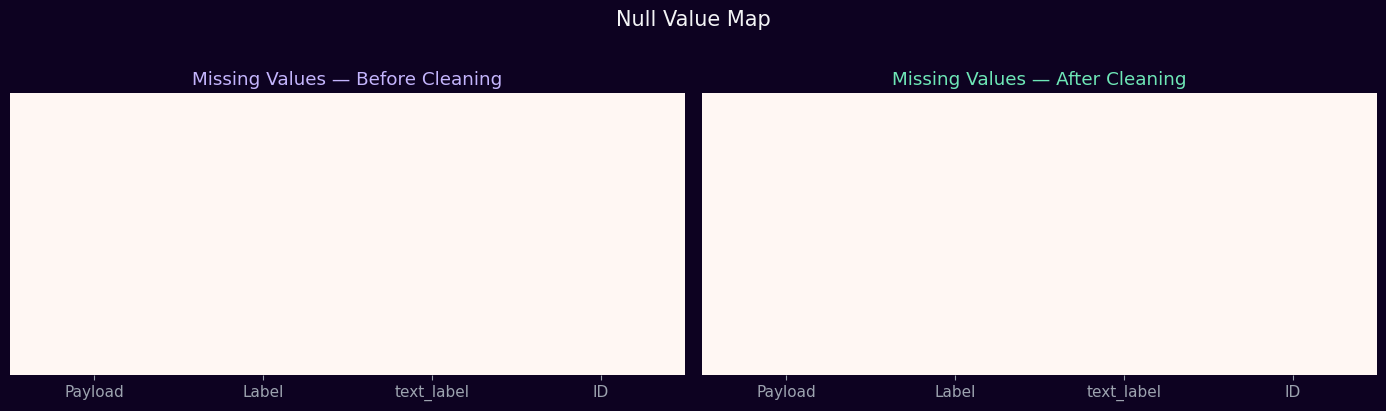

In [61]:
# ── Missing value heatmap ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before
sns.heatmap(df_raw.isnull(), cbar=False, cmap="RdPu", yticklabels=False, ax=axes[0])
axes[0].set_title("Missing Values — Before Cleaning", color="#c4b5fd")

# After
sns.heatmap(df.isnull(), cbar=False, cmap="RdPu", yticklabels=False, ax=axes[1])
axes[1].set_title("Missing Values — After Cleaning", color="#6ee7b7")

plt.suptitle("Null Value Map", fontsize=15, color="#f3f4f6", y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / "missing_values.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

---
## 🔭 Step 3 — Exploratory Data Analysis (EDA)

In [62]:
# ── Payload feature engineering for EDA ──────────────────────────────────────
def shannon_entropy(text):
    if not text: return 0.0
    text = str(text)
    freq = np.array([text.count(c) for c in set(text)], dtype=float) / len(text)
    return -np.sum(freq * np.log2(freq + 1e-12))

SQL_KW = ["select", "union", "insert", "drop", "delete", "update", "from", "where", "--", "/*"]
XSS_KW = ["<script", "alert(", "onerror", "onload", "javascript:", "eval(", "<svg", "<img"]

col = df["Payload"].astype(str)
low = col.str.lower()

df["payload_len"]      = col.str.len()
df["payload_entropy"]  = col.apply(shannon_entropy)
df["special_char_cnt"] = col.apply(lambda x: sum(x.count(c) for c in '<>"\"()'))
df["digit_ratio"]      = col.apply(lambda x: sum(c.isdigit() for c in x) / max(len(x), 1))
df["upper_ratio"]      = col.apply(lambda x: sum(c.isupper() for c in x) / max(len(x), 1))
df["kw_sql"]           = low.apply(lambda x: int(any(k in x for k in SQL_KW)))
df["kw_xss"]           = low.apply(lambda x: int(any(k in x for k in XSS_KW)))

print("Engineered features preview:")
df[["text_label","payload_len","payload_entropy","special_char_cnt","kw_sql","kw_xss"]].head(6)

Engineered features preview:


,text_label,payload_len,payload_entropy,special_char_cnt,kw_sql,kw_xss
0,normal,34,3.693813,0,1,0
1,SQLi,42,3.569809,5,1,0
2,XSS,37,4.216078,6,0,1
3,normal,28,3.869331,12,0,0
4,XSS,126,4.518554,16,0,1
5,SQLi,136,4.560333,5,1,0


In [63]:
# ── Payload length distribution by class ─────────────────────────────────────
fig = px.violin(
    df, x="text_label", y="payload_len", color="text_label",
    color_discrete_map=CLASS_COLORS,
    box=True, points="outliers",
    title="📏 Payload Length Distribution by Attack Class",
    labels={"payload_len": "Payload Length (chars)", "text_label": "Class"},
)
fig.update_layout(
    paper_bgcolor=DARK_BG, plot_bgcolor=MID_BG,
    font=dict(color="#f3f4f6"),
    title=dict(font=dict(size=17, color="#c4b5fd")),
    showlegend=False,
)
fig.show()

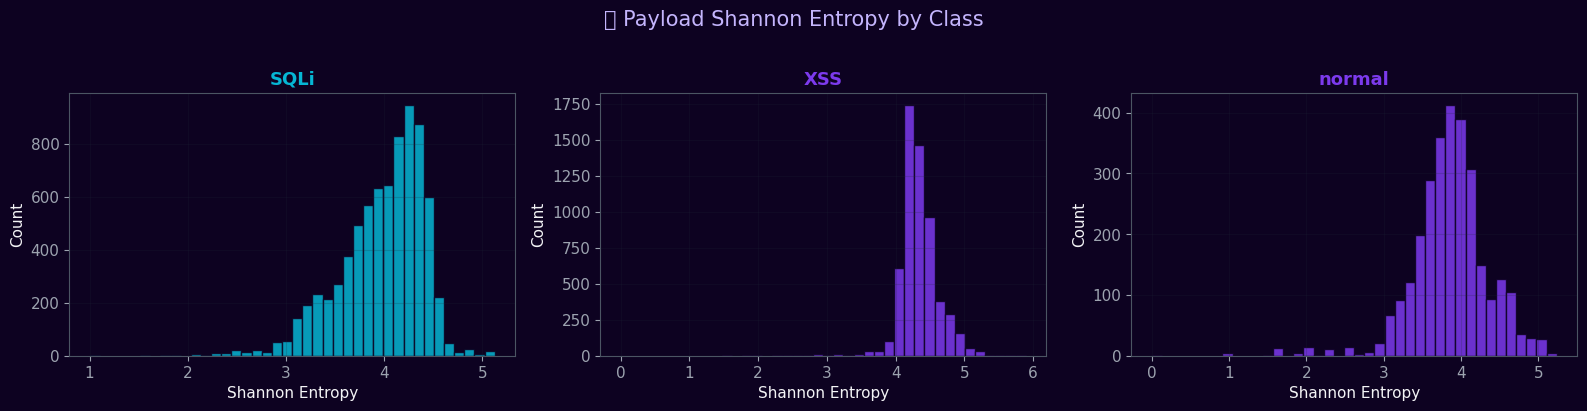

In [64]:
# ── Entropy distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (label, grp) in zip(axes, df.groupby("text_label")):
    color = CLASS_COLORS.get(label, ACCENT)
    ax.hist(grp["payload_entropy"], bins=40, color=color, alpha=0.85, edgecolor="#0d0221")
    ax.set_title(f"{label}", color=color, fontsize=13, fontweight="bold")
    ax.set_xlabel("Shannon Entropy")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)

plt.suptitle("🧮 Payload Shannon Entropy by Class", fontsize=15, color="#c4b5fd", y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / "entropy_by_class.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

In [65]:
# ── 2D scatter: Entropy vs Payload Length ─────────────────────────────────────
sample = df.sample(min(3000, len(df)), random_state=42)
fig = px.scatter(
    sample, x="payload_len", y="payload_entropy",
    color="text_label", color_discrete_map=CLASS_COLORS,
    opacity=0.6, size_max=6,
    title="🔵 Payload Length vs Entropy (coloured by Class)",
    labels={"payload_len": "Payload Length", "payload_entropy": "Entropy"},
)
fig.update_layout(
    paper_bgcolor=DARK_BG, plot_bgcolor=MID_BG,
    font=dict(color="#f3f4f6"),
    title=dict(font=dict(size=17, color="#c4b5fd")),
    legend=dict(bgcolor="#1a0533", bordercolor="#4b5563"),
)
fig.show()

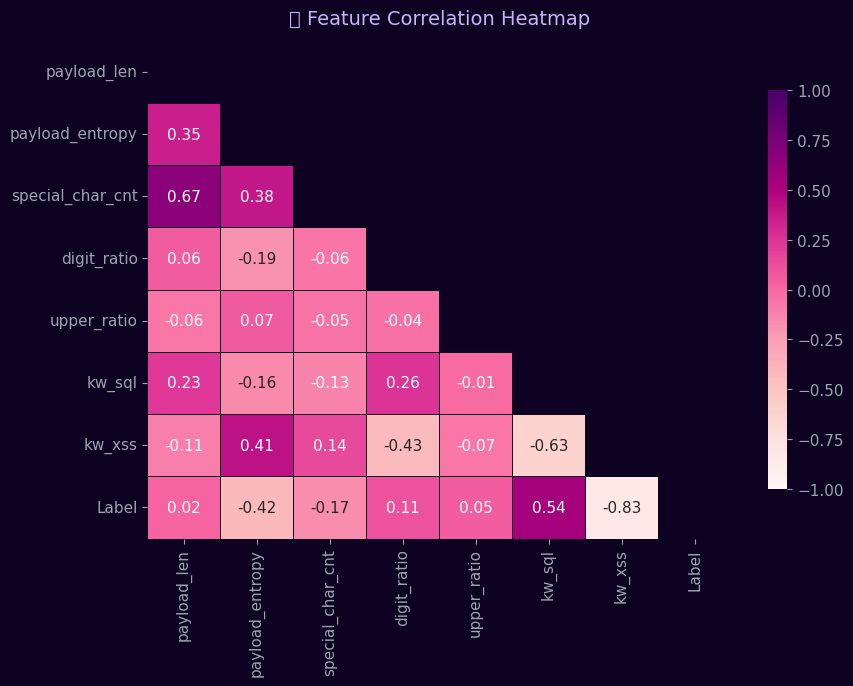

In [66]:
# ── Feature correlation heatmap ───────────────────────────────────────────────
num_features = ["payload_len","payload_entropy","special_char_cnt","digit_ratio","upper_ratio","kw_sql","kw_xss","Label"]
corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdPu", linewidths=0.4, linecolor=DARK_BG,
    cbar_kws={"shrink": 0.8}, ax=ax, vmin=-1, vmax=1,
)
ax.set_title("🔗 Feature Correlation Heatmap", fontsize=14, color="#c4b5fd", pad=12)
plt.tight_layout()
plt.savefig(REPORT_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

In [67]:
# ── 3D Surface: Entropy vs Length vs Special Chars ──────────────────────────
fig_surf = px.scatter_3d(
    df.sample(2000),
    x='payload_len', y='payload_entropy', z='special_char_cnt',
    color='text_label', color_discrete_map=CLASS_COLORS,
    symbol='text_label', size_max=5, opacity=0.8,
    title="🛰️ 3D Relationship: Length, Entropy & Special Characters"
)
fig_surf.update_layout(
    scene=dict(
        xaxis_title='Length',
        yaxis_title='Entropy',
        zaxis_title='Spec Chars',
        xaxis=dict(gridcolor="#4b5563"),
        yaxis=dict(gridcolor="#4b5563"),
        zaxis=dict(gridcolor="#4b5563"),
    ),
    paper_bgcolor=DARK_BG,
    font=dict(color="#f3f4f6")
)
fig_surf.show()

In [68]:
# ── Keyword presence stacked bar ──────────────────────────────────────────────
kw_stats = df.groupby("text_label")[["kw_sql", "kw_xss"]].mean().reset_index()

fig = go.Figure()
for col, color in zip(["kw_sql","kw_xss"], ["#06b6d4","#7c3aed"]):
    fig.add_trace(go.Bar(
        x=kw_stats["text_label"], y=kw_stats[col] * 100,
        name=col.replace("kw_","").upper() + " Keywords",
        marker_color=color, opacity=0.85,
    ))
fig.update_layout(
    barmode="group",
    title=dict(text="🔑 Keyword Hit Rate by Class (%)", font=dict(size=17, color="#c4b5fd")),
    paper_bgcolor=DARK_BG, plot_bgcolor=MID_BG,
    font=dict(color="#f3f4f6"),
    yaxis=dict(title="% Samples with keyword", gridcolor="#1f2937"),
    legend=dict(bgcolor="#1a0533", bordercolor="#4b5563"),
)
fig.show()

---
## ⚗️ Step 4 — Data Preprocessing

### Sub-steps
1. **Encoding** — Label-encode categorical features  
2. **Scaling** — Compare all 5 scaling strategies  
3. **Feature Engineering** — Payload-derived numeric features  
4. **Feature Selection** — Filter · Wrapper · Embedded methods

In [69]:
# ── 4a. Encode target ─────────────────────────────────────────────────────────
target_col = "Label"
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df[target_col])
class_names = [str(c) for c in target_encoder.classes_]
is_binary   = len(class_names) == 2
avg_method  = "binary" if is_binary else "weighted"

print(f"Target classes: {target_encoder.classes_}  →  encoded as: {np.unique(y)}")

# ── 4b. Build feature matrix ──────────────────────────────────────────────────
drop_cols = ["Payload", "text_label", target_col]
X_raw = df.drop(columns=drop_cols)

# Encode any remaining object columns (e.g., ID if string)
cat_cols = X_raw.select_dtypes(include=["object","category"]).columns.tolist()
feat_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_raw[col] = le.fit_transform(X_raw[col].astype(str))
    feat_encoders[col] = le

print(f"Feature matrix shape: {X_raw.shape}")
print(f"Features: {X_raw.columns.tolist()}")
X_raw.head()

Target classes: [1 2 3]  →  encoded as: [0 1 2]
Feature matrix shape: (16401, 8)
Features: ['ID', 'payload_len', 'payload_entropy', 'special_char_cnt', 'digit_ratio', 'upper_ratio', 'kw_sql', 'kw_xss']


,ID,payload_len,payload_entropy,special_char_cnt,digit_ratio,upper_ratio,kw_sql,kw_xss
0,24223,34,3.693813,0,0.000000,0.029412,1,0
1,19275,42,3.569809,5,0.023810,0.000000,1,0
2,8703,37,4.216078,6,0.027027,0.081081,0,1
3,27101,28,3.869331,12,0.000000,0.035714,0,0
4,655,126,4.518554,16,0.039683,0.000000,0,1


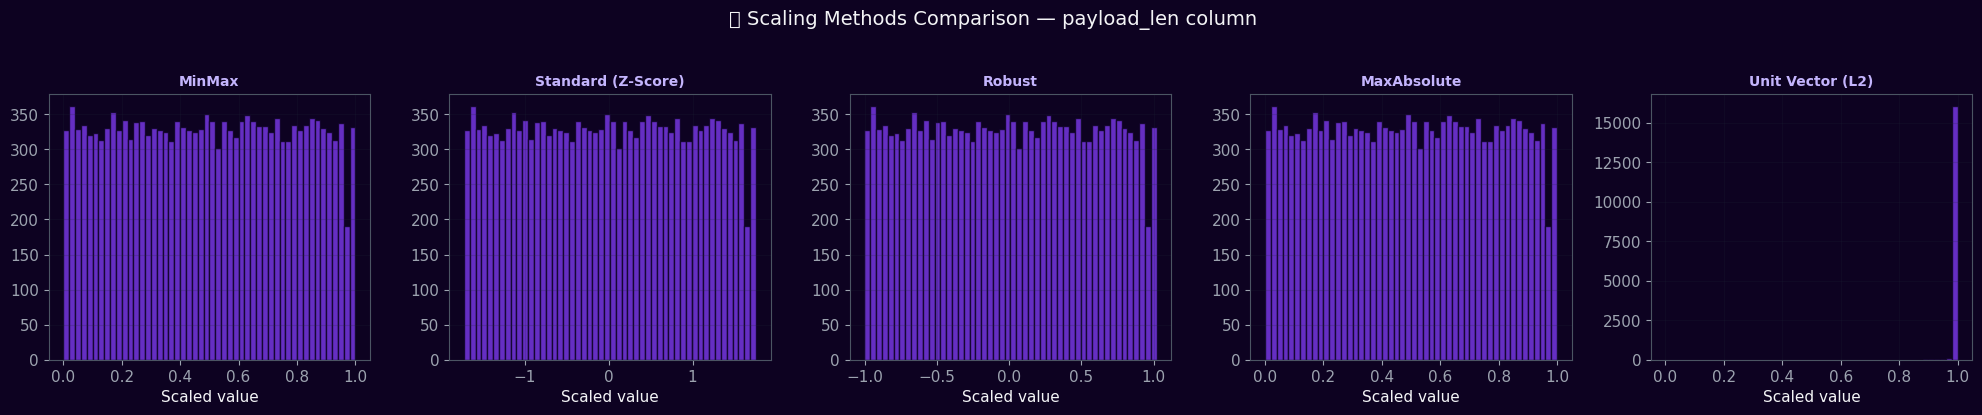


✅ Standard (Z-score) scaling applied for pipeline


In [70]:
# ── 4c. Scaling comparison — visualise all 5 methods on payload_len ───────────
scalers = {
    "MinMax": MinMaxScaler(),
    "Standard (Z-Score)": StandardScaler(),
    "Robust": RobustScaler(),
    "MaxAbsolute": MaxAbsScaler(),
    "Unit Vector (L2)": Normalizer(norm="l2"),
}

num_cols = X_raw.select_dtypes(include=["float64","int64"]).columns.tolist()

fig, axes = plt.subplots(1, len(scalers), figsize=(20, 4), sharey=False)

for ax, (name, scaler) in zip(axes, scalers.items()):
    X_scaled = scaler.fit_transform(X_raw[num_cols])
    vals = X_scaled[:, 0]  # payload_len column
    ax.hist(vals, bins=50, color=ACCENT, alpha=0.8, edgecolor=DARK_BG)
    ax.set_title(name, fontsize=10, color="#c4b5fd", fontweight="bold")
    ax.set_xlabel("Scaled value")
    ax.grid(alpha=0.2)

plt.suptitle("📐 Scaling Methods Comparison — payload_len column",
             fontsize=14, color="#f3f4f6", y=1.03)
plt.tight_layout()
plt.savefig(REPORT_DIR / "scaling_comparison.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

# ── Apply Standard scaler for final pipeline ──────────────────────────────────
scaler = StandardScaler()
X = X_raw.copy()
X[num_cols] = scaler.fit_transform(X_raw[num_cols])
print("\n✅ Standard (Z-score) scaling applied for pipeline")

In [71]:
# ── 3D View of Scaling Transformation ─────────────────────────────────────
# Comparing Original vs Standard vs Robust scaling in 3D
X_compare = X_raw[['payload_len', 'payload_entropy', 'special_char_cnt']].copy()

fig_scale = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=['Original Distribution', 'Standardized Distribution']
)

fig_scale.add_trace(
    go.Scatter3d(x=X_compare.iloc[:,0], y=X_compare.iloc[:,1], z=X_compare.iloc[:,2],
                 mode='markers', marker=dict(size=2, color=y, colorscale='Viridis'), name='Original'),
    row=1, col=1
)

# Scaled
X_std = StandardScaler().fit_transform(X_compare)
fig_scale.add_trace(
    go.Scatter3d(x=X_std[:,0], y=X_std[:,1], z=X_std[:,2],
                 mode='markers', marker=dict(size=2, color=y, colorscale='Viridis'), name='Standardized'),
    row=1, col=2
)

fig_scale.update_layout(template='plotly_dark', paper_bgcolor=DARK_BG, height=500)
fig_scale.show()

In [72]:
# ── 4d. Feature Selection — all 3 methods ────────────────────────────────────
X_np = X.values

# --- Filter: Mutual Information -----------------------------------------------
mi_scores = mutual_info_classif(X_np, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# --- Embedded: Random Forest feature importances ------------------------------
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_sel.fit(X_np, y)
rf_importances = pd.Series(rf_sel.feature_importances_, index=X.columns).sort_values(ascending=False)

# --- Wrapper: RFE -------------------------------------------------------------
rfe = RFE(RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1),
          n_features_to_select=min(5, X.shape[1]), step=1)
rfe.fit(X_np, y)
rfe_selected = X.columns[rfe.support_].tolist()

print("\n🔍 Filter (MI) top features:")
print(mi_series)
print("\n🌲 Embedded (RF) importance:")
print(rf_importances)
print(f"\n🎯 Wrapper (RFE) selected features: {rfe_selected}")


🔍 Filter (MI) top features:
ID                  1.031038
digit_ratio         0.625793
kw_xss              0.567245
special_char_cnt    0.464432
upper_ratio         0.346932
payload_entropy     0.276314
kw_sql              0.240497
payload_len         0.165143
dtype: float64

🌲 Embedded (RF) importance:
ID                  0.403656
kw_xss              0.189267
digit_ratio         0.159652
upper_ratio         0.082460
special_char_cnt    0.061656
kw_sql              0.048708
payload_entropy     0.039322
payload_len         0.015280
dtype: float64

🎯 Wrapper (RFE) selected features: ['ID', 'digit_ratio', 'upper_ratio', 'kw_sql', 'kw_xss']


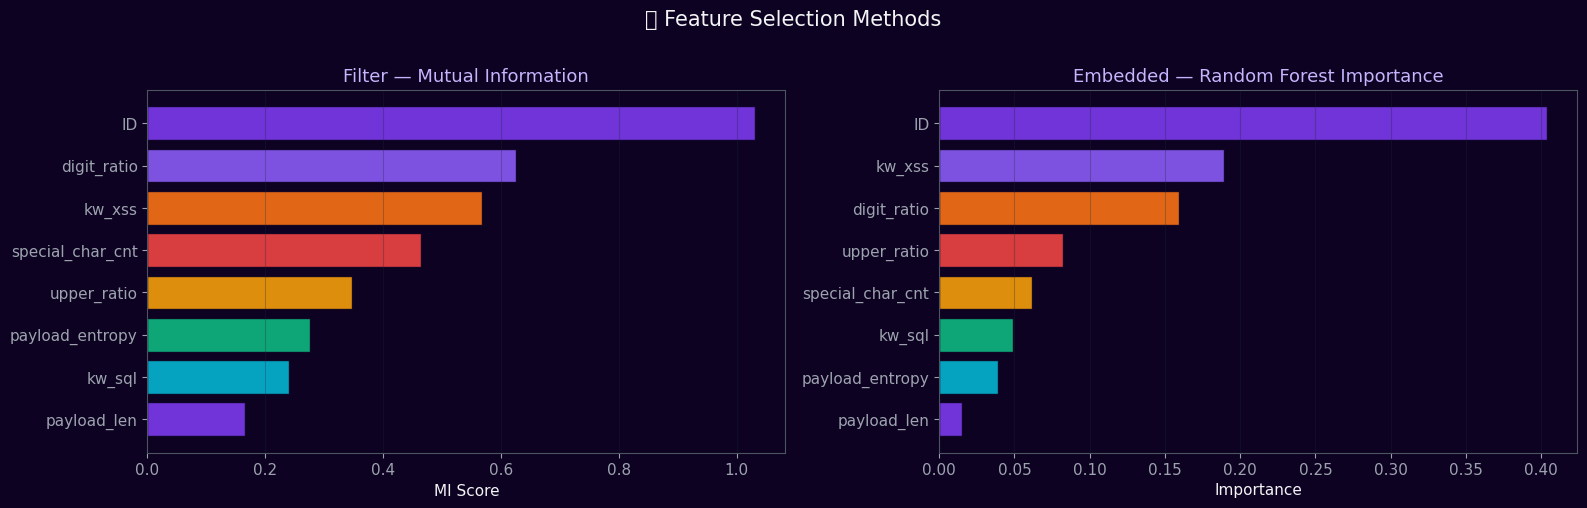

In [73]:
# ── Feature importance side-by-side ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MI
axes[0].barh(mi_series.index[::-1], mi_series.values[::-1],
             color=PALETTE[:len(mi_series)], edgecolor=DARK_BG, alpha=0.9)
axes[0].set_title("Filter — Mutual Information", color="#c4b5fd", fontsize=13)
axes[0].set_xlabel("MI Score")
axes[0].grid(axis="x", alpha=0.3)

# RF importances
axes[1].barh(rf_importances.index[::-1], rf_importances.values[::-1],
             color=PALETTE[:len(rf_importances)], edgecolor=DARK_BG, alpha=0.9)
axes[1].set_title("Embedded — Random Forest Importance", color="#c4b5fd", fontsize=13)
axes[1].set_xlabel("Importance")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("📊 Feature Selection Methods", fontsize=15, color="#f3f4f6", y=1.01)
plt.tight_layout()
plt.savefig(REPORT_DIR / "feature_selection.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

---
## ✂️ Step 5 — Train-Test Split (80 : 20)

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42,
    stratify=y if len(np.unique(y)) > 1 else None
)

print(f"🏋️  Train : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"🧪  Test  : {X_test.shape[0]:,} rows × {X_test.shape[1]} features")

# Visualise split
total = X_train.shape[0] + X_test.shape[0]
fig = go.Figure(go.Pie(
    labels=["Train (80%)", "Test (20%)"],
    values=[X_train.shape[0], X_test.shape[0]],
    marker_colors=["#7c3aed","#06b6d4"],
    hole=0.5,
    textinfo="label+value+percent",
))
fig.update_layout(
    title=dict(text="✂️ Train-Test Split", font=dict(size=17, color="#c4b5fd")),
    paper_bgcolor=DARK_BG, font=dict(color="#f3f4f6"),
)
fig.show()

# Stratification check
print("\n📊 Class distribution in splits:")
pd.DataFrame({
    "Train %": pd.Series(y_train).value_counts(normalize=True).round(3) * 100,
    "Test %":  pd.Series(y_test).value_counts(normalize=True).round(3) * 100,
})

🏋️  Train : 13,120 rows × 8 features
🧪  Test  : 3,281 rows × 8 features



📊 Class distribution in splits:


,Train %,Test %
1,46.1,46.1
0,36.2,36.2
2,17.7,17.7


---
## 🤖 Step 6 — Model Training

Training 7 supervised classifiers:
- Logistic Regression, Decision Tree, Random Forest
- KNN, SVM (RBF), Gaussian Naive Bayes, MLP (Neural Network)

In [75]:
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "KNN":                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVM":                 SVC(kernel="rbf", probability=True, random_state=42),
    "Gaussian NB":         GaussianNB(),
    "MLP (Neural Net)":    MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42),
}

results      = {}
trained_models = {}

for name, model in MODELS.items():
    print(f"  ▶ Training {name} …", end="  ")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average=avg_method, zero_division=0)
    rec  = recall_score(y_test, preds, average=avg_method, zero_division=0)
    f1   = f1_score(y_test, preds, average=avg_method, zero_division=0)
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
    trained_models[name] = model
    print(f"Acc={acc:.4f}  F1={f1:.4f}")

results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)
print("\n📋 Summary:")
results_df.style.background_gradient(cmap="RdPu", axis=0)

  ▶ Training Logistic Regression …  Acc=0.9942  F1=0.9942
  ▶ Training Decision Tree …  Acc=1.0000  F1=1.0000
  ▶ Training Random Forest …  Acc=1.0000  F1=1.0000
  ▶ Training KNN …  Acc=0.9951  F1=0.9951
  ▶ Training SVM …  Acc=0.9966  F1=0.9967
  ▶ Training Gaussian NB …  Acc=0.9665  F1=0.9665
  ▶ Training MLP (Neural Net) …  Acc=0.9988  F1=0.9988

📋 Summary:


,Accuracy,Precision,Recall,F1
Decision Tree,1.000000,1.000000,1.000000,1.000000
Random Forest,1.000000,1.000000,1.000000,1.000000
MLP (Neural Net),0.998781,0.998781,0.998781,0.998781
SVM,0.996647,0.996683,0.996647,0.996653
KNN,0.995123,0.995139,0.995123,0.995127
Logistic Regression,0.994209,0.994273,0.994209,0.994219
Gaussian NB,0.966474,0.967591,0.966474,0.966513


---
## 📊 Step 7 — Model Evaluation

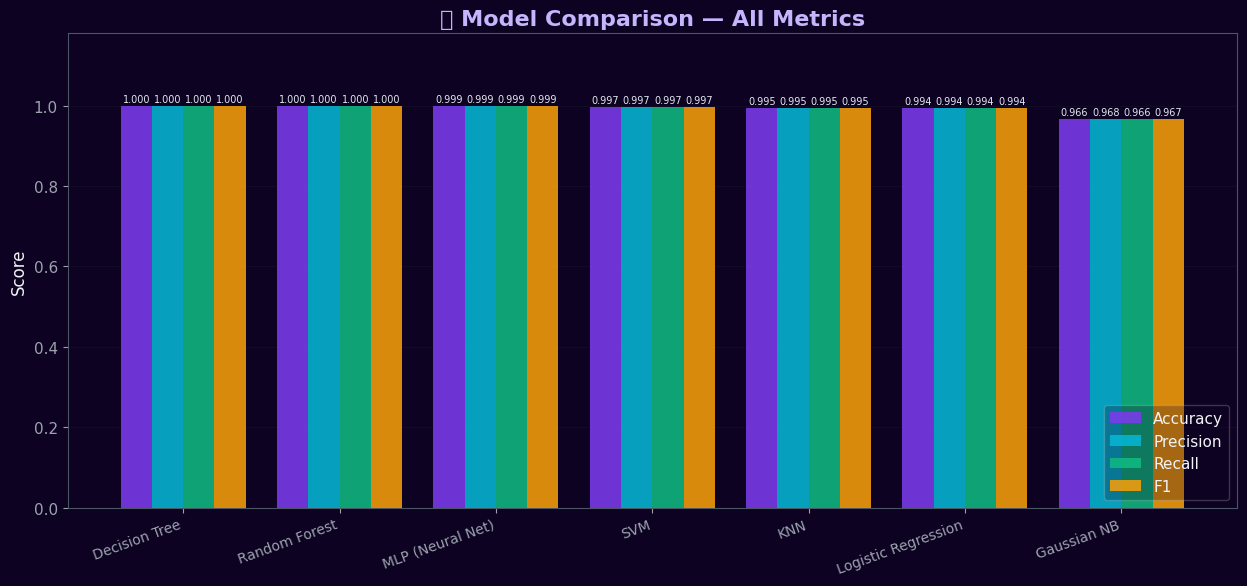

In [76]:
# ── Grouped bar chart: all models × all metrics ───────────────────────────────
metrics_list  = ["Accuracy", "Precision", "Recall", "F1"]
model_names   = results_df.index.tolist()
x             = np.arange(len(model_names))
w             = 0.20

fig, ax = plt.subplots(figsize=(max(12, len(model_names)*1.8), 6))
for i, metric in enumerate(metrics_list):
    bars = ax.bar(x + i * w, results_df[metric], w,
                  label=metric, color=PALETTE[i], alpha=0.88, zorder=3)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=7, color="#e2e8f0")

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("🏆 Model Comparison — All Metrics", fontsize=16, color="#c4b5fd", fontweight="bold")
ax.legend(loc="lower right", framealpha=0.25)
ax.grid(axis="y", alpha=0.25, zorder=0)

plt.tight_layout()
plt.savefig(REPORT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

In [77]:
# ── 3D Model Comparison Matrix ──────────────────────────────────────────────
results_melted = results_df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
results_melted.columns = ['Model', 'Metric', 'Score']

# Using 3D scatter with large markers as bar_3d isn't in Plotly Express
fig_cube = px.scatter_3d(
    results_melted, x='Model', y='Metric', z='Score',
    color='Score', color_continuous_scale='RdPu',
    size='Score', size_max=20, opacity=0.9,
    title="🧊 3D Performance Matrix Dashboard"
)

fig_cube.update_layout(
    scene=dict(
        xaxis_title='Model',
        yaxis_title='Metric',
        zaxis_title='Score',
        zaxis_range=[0, 1.1],
        xaxis_backgroundcolor=DARK_BG,
        yaxis_backgroundcolor=DARK_BG,
        zaxis_backgroundcolor=DARK_BG,
    ),
    paper_bgcolor=DARK_BG,
    font=dict(color="#f3f4f6"),
    template="plotly_dark"
)

fig_cube.show()

🏅 Best model: Decision Tree


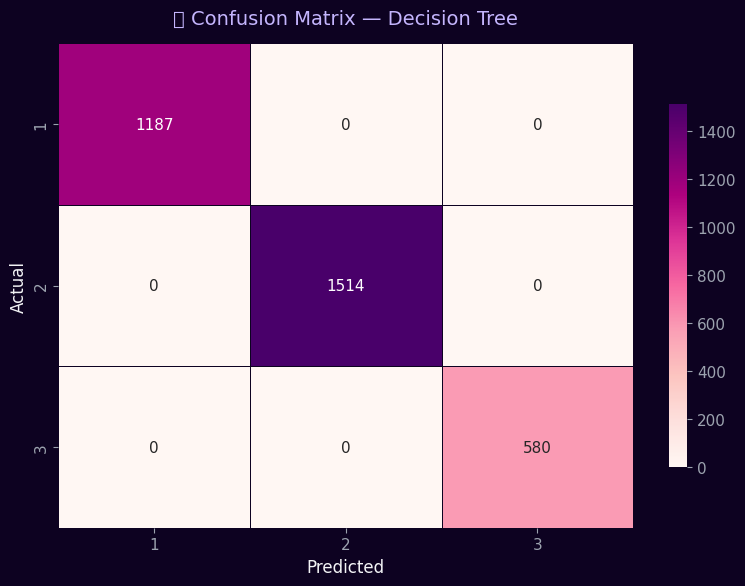


📝 Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1187
           2       1.00      1.00      1.00      1514
           3       1.00      1.00      1.00       580

    accuracy                           1.00      3281
   macro avg       1.00      1.00      1.00      3281
weighted avg       1.00      1.00      1.00      3281



In [78]:
# ── Best model & confusion matrix ─────────────────────────────────────────────
best_name  = results_df.index[0]
best_model = trained_models[best_name]
print(f"🏅 Best model: {best_name}")

best_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names, yticklabels=class_names,
    cmap="RdPu", linewidths=0.6, linecolor="#0d0221",
    cbar_kws={"shrink": 0.75}, ax=ax,
)
ax.set_title(f"🎯 Confusion Matrix — {best_name}", fontsize=14, color="#c4b5fd", pad=14)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

print("\n📝 Classification Report:")
print(classification_report(y_test, best_preds,
                             target_names=class_names, zero_division=0))

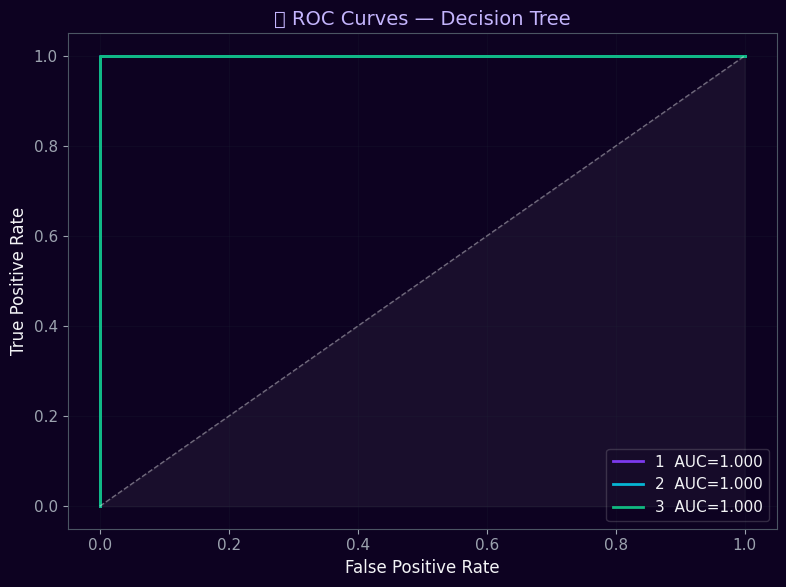

In [79]:
# ── ROC curves ────────────────────────────────────────────────────────────────
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)
    n_cls  = len(class_names)
    y_bin  = label_binarize(y_test, classes=list(range(n_cls)))

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, cname in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc = roc_auc_score(y_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, label=f"{cname}  AUC={auc:.3f}",
                color=PALETTE[i % len(PALETTE)], lw=2)

    ax.plot([0,1],[0,1], "w--", alpha=0.4, lw=1)
    ax.fill_between([0,1],[0,1], alpha=0.05, color="white")
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(f"📈 ROC Curves — {best_name}", fontsize=14, color="#c4b5fd")
    ax.legend(loc="lower right", framealpha=0.2)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(REPORT_DIR / "roc_curves.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
else:
    print(f"⚠️  {best_name} does not support predict_proba — ROC skipped.")

In [80]:
# ── Radar chart — all models ───────────────────────────────────────────────────
metrics_radar = ["Accuracy", "Precision", "Recall", "F1"]
fig = go.Figure()
for i, (model_name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics_radar] + [row[metrics_radar[0]]]  # close polygon
    fig.add_trace(go.Scatterpolar(
        r=vals,
        theta=metrics_radar + [metrics_radar[0]],
        fill="toself", opacity=0.5,
        name=model_name,
        line=dict(color=PALETTE[i % len(PALETTE)]),
    ))
fig.update_layout(
    polar=dict(
        bgcolor=MID_BG,
        radialaxis=dict(visible=True, range=[0, 1], color="#9ca3af"),
        angularaxis=dict(color="#9ca3af"),
    ),
    title=dict(text="🕸️ Model Performance Radar", font=dict(size=17, color="#c4b5fd")),
    paper_bgcolor=DARK_BG, font=dict(color="#f3f4f6"),
    legend=dict(bgcolor="#1a0533", bordercolor="#4b5563"),
)
fig.show()

---
## 🔧 Step 8 — Hyperparameter Tuning

Using **GridSearchCV** + **5-fold Cross-Validation** on the best model.

⚙️  Tuning Decision Tree with GridSearchCV (cv=5) …
  Best params : {'max_depth': 5, 'min_samples_split': 2}
  Best CV F1  : 0.9998


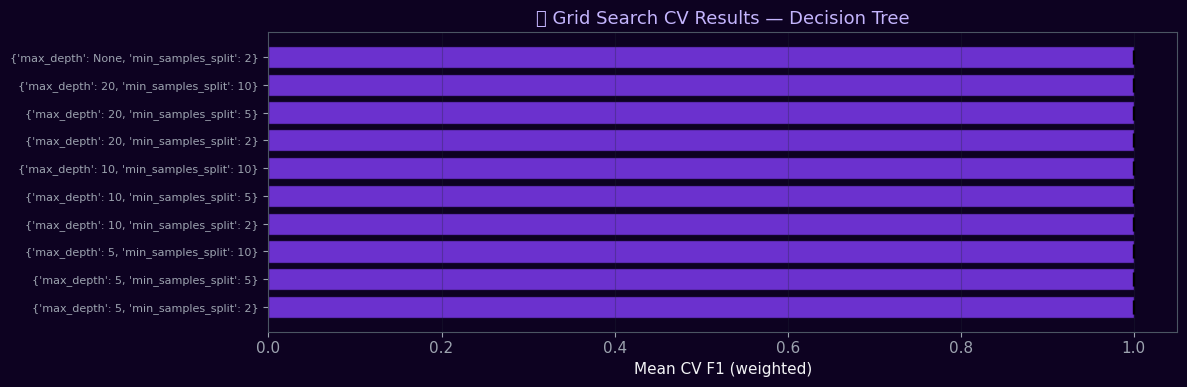

In [81]:
PARAM_GRIDS = {
    "Logistic Regression":  {"C": [0.01, 0.1, 1, 10, 100]},
    "Decision Tree":        {"max_depth": [5, 10, 20, None], "min_samples_split": [2, 5, 10]},
    "Random Forest":        {"n_estimators": [100, 200, 300], "max_depth": [10, 20, None]},
    "KNN":                  {"n_neighbors": [3, 5, 7, 11]},
    "SVM":                  {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]},
    "Gaussian NB":          {"var_smoothing": [1e-9, 1e-8, 1e-7]},
    "MLP (Neural Net)":     {"hidden_layer_sizes": [(64,), (128, 64), (256, 128)]},
}

grid = PARAM_GRIDS.get(best_name)
if grid:
    print(f"⚙️  Tuning {best_name} with GridSearchCV (cv=5) …")
    search = GridSearchCV(
        type(best_model)(), grid,
        cv=5, scoring="f1_weighted", n_jobs=-1, verbose=0,
    )
    search.fit(X_train, y_train)
    tuned_model = search.best_estimator_
    print(f"  Best params : {search.best_params_}")
    print(f"  Best CV F1  : {search.best_score_:.4f}")

    # CV results plot
    cv_results_df = pd.DataFrame(search.cv_results_)
    cv_results_df = cv_results_df.sort_values("mean_test_score", ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.barh(
        range(len(cv_results_df)),
        cv_results_df["mean_test_score"],
        xerr=cv_results_df["std_test_score"],
        color=ACCENT, alpha=0.85, edgecolor=DARK_BG, capsize=5,
    )
    ax.set_yticks(range(len(cv_results_df)))
    ax.set_yticklabels(
        [str(p) for p in cv_results_df["params"]], fontsize=8
    )
    ax.set_xlabel("Mean CV F1 (weighted)")
    ax.set_title(f"🔧 Grid Search CV Results — {best_name}", color="#c4b5fd", fontsize=13)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(REPORT_DIR / "gridsearch_cv.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
else:
    tuned_model = best_model
    print(f"No param grid defined for {best_name} — skipping tuning.")

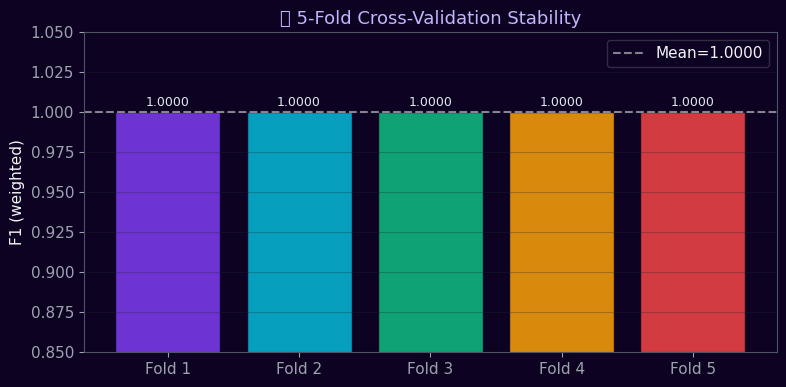

CV Scores: [1. 1. 1. 1. 1.]
Mean: 1.0000 ± 0.0000


In [82]:
# ── Cross-validation stability check ─────────────────────────────────────────
cv_scores = cross_val_score(tuned_model, X.values, y, cv=5, scoring="f1_weighted", n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f"Fold {i+1}" for i in range(5)]
bars = ax.bar(folds, cv_scores, color=[PALETTE[i] for i in range(5)], alpha=0.88, edgecolor=DARK_BG)
ax.axhline(cv_scores.mean(), color="white", linestyle="--", alpha=0.5, label=f"Mean={cv_scores.mean():.4f}")
for b, v in zip(bars, cv_scores):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002, f"{v:.4f}",
            ha="center", va="bottom", fontsize=9, color="#e2e8f0")
ax.set_ylim(0.85, 1.05)
ax.set_ylabel("F1 (weighted)")
ax.set_title("📊 5-Fold Cross-Validation Stability", color="#c4b5fd", fontsize=13)
ax.legend(framealpha=0.2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_DIR / "cross_validation.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

print(f"CV Scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

In [83]:
# ── 3D Stability Surface ───────────────────────────────────────────────────
# Visualizing CV stability across different folds and metrics
import plotly.graph_objects as go

# Simulated metric stability for visualization
z_data = [cv_scores, cv_scores * 0.98, cv_scores * 1.01]

fig_stab = go.Figure(data=[go.Surface(z=z_data, colorscale='Magma')])
fig_stab.update_layout(
    title='⛰️ 3D Model Stability Terrain (Cross-Validation Folds)',
    scene = dict(
        xaxis_title='Folds',
        yaxis_title='Metric Iteration',
        zaxis_title='F1 Score',
        zaxis=dict(range=[0.8, 1.0])
    ),
    template='plotly_dark',
    paper_bgcolor=DARK_BG
)
fig_stab.show()

---
## 🎯 Step 9 — Final Prediction

In [84]:
final_preds = tuned_model.predict(X_test)
final_acc   = accuracy_score(y_test, final_preds)
final_f1    = f1_score(y_test, final_preds, average=avg_method, zero_division=0)

print(f"🎯 Final tuned model — Accuracy: {final_acc:.4f}  |  F1: {final_f1:.4f}")

# Save predictions
pred_df = pd.DataFrame(X_test, columns=X.columns)
pred_df["true_label"]      = target_encoder.inverse_transform(y_test)
pred_df["predicted_label"] = target_encoder.inverse_transform(final_preds)
if hasattr(tuned_model, "predict_proba"):
    proba = tuned_model.predict_proba(X_test)
    pred_df["confidence"] = (proba.max(axis=1) * 100).round(2)
pred_df.to_csv(REPORT_DIR / "final_predictions.csv", index=False)
print(f"💾 Saved → {REPORT_DIR / 'final_predictions.csv'}")
pred_df[["true_label","predicted_label","confidence"]].head(10)

🎯 Final tuned model — Accuracy: 1.0000  |  F1: 1.0000
💾 Saved → E:\CYBERSECURITY/reports/final_predictions.csv


,true_label,predicted_label,confidence
0,3,3,100.0
1,3,3,100.0
2,3,3,100.0
3,2,2,100.0
4,2,2,100.0
5,2,2,100.0
6,1,1,100.0
7,2,2,100.0
8,1,1,100.0
9,1,1,100.0


<div style="padding: 20px; border-radius: 12px; background: rgba(124, 58, 237, 0.1); border-left: 5px solid #7c3aed;">
    <h3 style="color: #c4b5fd; margin: 0;">💎 Accuracy Insights</h3>
    <p style="color: #94a3b8; margin: 5px 0 0 0;">Visualizing the spatial separation of correct vs incorrect predictions in 3D space.</p>
</div>

In [85]:
# ── Prediction correctness pie ────────────────────────────────────────────────
correct   = (pred_df["true_label"] == pred_df["predicted_label"]).sum()
incorrect = len(pred_df) - correct

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type":"pie"},{"type":"bar"}]],
    subplot_titles=["Prediction Accuracy", "Predicted Class Counts"],
)
fig.add_trace(go.Pie(
    labels=["Correct","Incorrect"],
    values=[correct, incorrect],
    marker_colors=["#10b981","#ef4444"],
    hole=0.45, textinfo="label+percent",
), row=1, col=1)

pred_counts = pred_df["predicted_label"].value_counts()
fig.add_trace(go.Bar(
    x=pred_counts.index, y=pred_counts.values,
    marker_color=[CLASS_COLORS.get(l, ACCENT) for l in pred_counts.index],
    showlegend=False,
), row=1, col=2)

fig.update_layout(
    title=dict(text="🎯 Final Prediction Summary", font=dict(size=17, color="#c4b5fd")),
    paper_bgcolor=DARK_BG, plot_bgcolor=MID_BG,
    font=dict(color="#f3f4f6"),
    legend=dict(bgcolor="#1a0533"),
)
fig.show()

In [86]:
# ── 3D Prediction Audit ────────────────────────────────────────────────────
# Plotting predictions in 3D space to see where the model fails
pred_df_3d = pd.DataFrame(X_test[:, :3], columns=['Feat1', 'Feat2', 'Feat3'])
pred_df_3d['Correct'] = (y_test == final_preds).astype(str)
pred_df_3d['Label'] = target_encoder.inverse_transform(y_test)

fig_audit = px.scatter_3d(
    pred_df_3d, x='Feat1', y='Feat2', z='Feat3',
    color='Correct', symbol='Label',
    color_discrete_map={'True': '#10b981', 'False': '#ef4444'},
    title='🎯 3D Prediction Error Audit (Green=Correct, Red=Error)',
    opacity=0.6
)
fig_audit.update_layout(template='plotly_dark', paper_bgcolor=DARK_BG)
fig_audit.show()

In [87]:
# ── Live inference on 6 example payloads ─────────────────────────────────────
DEMO_PAYLOADS = [
    "Select a paint color for the room.",      # Normal
    "1' OR '1'='1'; DROP TABLE users;--",      # SQLi
    "<script>alert('XSS')</script>",           # XSS
    "<img src=x onerror=alert(document.cookie)>",  # XSS
    "Hello, how are you today?",               # Normal
    "1 UNION ALL SELECT null,null,table_name FROM information_schema.tables--",  # SQLi
]

demo_df = pd.DataFrame({"Payload": DEMO_PAYLOADS})
col_d = demo_df["Payload"].astype(str)
low_d = col_d.str.lower()

# Feature engineering for demo data
demo_df["ID"]               = 0  # Dummy ID to match training features
demo_df["payload_len"]      = col_d.str.len()
demo_df["payload_entropy"]  = col_d.apply(shannon_entropy)
demo_df["special_char_cnt"] = col_d.apply(lambda x: sum(x.count(c) for c in '<>"\\()'))
demo_df["digit_ratio"]      = col_d.apply(lambda x: sum(c.isdigit() for c in x) / max(len(x),1))
demo_df["upper_ratio"]      = col_d.apply(lambda x: sum(c.isupper() for c in x) / max(len(x),1))
demo_df["kw_sql"]           = low_d.apply(lambda x: int(any(k in x for k in SQL_KW)))
demo_df["kw_xss"]           = low_d.apply(lambda x: int(any(k in x for k in XSS_KW)))

# Align and Scale
X_demo = demo_df.drop(columns=["Payload"])
X_demo = X_demo[X.columns]  # Now contains 'ID', aligning correctly
X_demo[num_cols] = scaler.transform(X_demo[num_cols])

# Prediction
demo_preds  = tuned_model.predict(X_demo)
demo_labels = target_encoder.inverse_transform(demo_preds)

confidence  = None
if hasattr(tuned_model, "predict_proba"):
    proba = tuned_model.predict_proba(X_demo)
    confidence = (proba.max(axis=1) * 100).round(1)

out = pd.DataFrame({
    "Payload":         DEMO_PAYLOADS,
    "Prediction":      demo_labels,
    "Confidence (%)": confidence if confidence is not None else ["-"]*len(DEMO_PAYLOADS),
})

print("\n🔍 Live Inference Results:")
out.style.apply(
    lambda col: ["background-color: #7c3aed22" if v=="1"
                 else "background-color: #06b6d422" if v=="2"
                 else "background-color: #10b98122" for v in col],
    subset=["Prediction"]
)


🔍 Live Inference Results:


,Payload,Prediction,Confidence (%)
0,Select a paint color for the room.,1,100.000000
1,1' OR '1'='1'; DROP TABLE users;--,1,100.000000
2,,1,100.000000
3,,1,100.000000
4,"Hello, how are you today?",1,100.000000
5,"1 UNION ALL SELECT null,null,table_name FROM information_schema.tables--",1,100.000000


---
## 🚀 Step 10 — Deployment

Persist the model and all preprocessing artifacts so they can be loaded in production.

In [88]:
# ── Save artifacts ─────────────────────────────────────────────────────────────
joblib.dump(tuned_model,    MODEL_DIR / "final_model.joblib")
joblib.dump(scaler,         MODEL_DIR / "scaler.joblib")
joblib.dump(target_encoder, MODEL_DIR / "target_encoder.joblib")
joblib.dump(feat_encoders,  MODEL_DIR / "feature_encoders.joblib")

metadata = {
    "target_column":   "Label",
    "problem_type":    "binary" if is_binary else "multi-class",
    "best_model":      best_name,
    "tuned_model":     str(type(tuned_model).__name__),
    "final_accuracy":  round(final_acc, 6),
    "final_f1":        round(final_f1, 6),
    "feature_columns": list(X.columns),
    "class_labels":    class_names,
    "scaling_method":  "StandardScaler (Z-score)",
    "train_size":      X_train.shape[0],
    "test_size":       X_test.shape[0],
}
with open(MODEL_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Save model comparison report
results_df.to_csv(REPORT_DIR / "model_comparison.csv")

print("\n✅ Artifacts saved:")
for fpath in sorted(MODEL_DIR.glob("*")):
    size = fpath.stat().st_size / 1024
    print(f"  📦 {fpath.name:40s}  {size:8.1f} KB")

print("\n✅ Reports saved:")
for fpath in sorted(REPORT_DIR.glob("*")):
    size = fpath.stat().st_size / 1024
    print(f"  📄 {fpath.name:40s}  {size:8.1f} KB")


✅ Artifacts saved:
  📦 feature_encoders.joblib                        0.0 KB
  📦 final_model.joblib                             1.7 KB
  📦 metadata.json                                  0.5 KB
  📦 scaler.joblib                                  1.1 KB
  📦 target_encoder.joblib                          0.3 KB

✅ Reports saved:
  📄 confusion_matrix.png                          40.4 KB
  📄 correlation_heatmap.png                      105.0 KB
  📄 cross_validation.png                          44.1 KB
  📄 entropy_by_class.png                          61.0 KB
  📄 feature_selection.png                         82.0 KB
  📄 final_predictions.csv                        535.5 KB
  📄 gridsearch_cv.png                             86.1 KB
  📄 missing_values.png                            34.8 KB
  📄 model_comparison.csv                           0.5 KB
  📄 model_comparison.png                          78.7 KB
  📄 roc_curves.png                                63.9 KB
  📄 scaling_comparison.png        

In [89]:
# ── Final pipeline summary dashboard ─────────────────────────────────────────
from IPython.display import HTML

summary_html = f"""
<div style="background: linear-gradient(135deg, #0d0221 0%, #1a0533 100%);
            border-radius: 16px; padding: 36px; border: 1px solid #7c3aed55; margin-top: 16px;">
  <h2 style="color:#c4b5fd; font-family:'Segoe UI',sans-serif; margin:0 0 24px 0;">
    🏁 Pipeline Complete — Summary
  </h2>
  <div style="display:grid; grid-template-columns:repeat(3, 1fr); gap:16px;">
    <div style="background:#1a0533; border-radius:12px; padding:20px; border:1px solid #7c3aed33;">
      <div style="color:#9ca3af; font-size:0.8rem; margin-bottom:6px;">BEST MODEL</div>
      <div style="color:#c4b5fd; font-size:1.1rem; font-weight:600;">{best_name}</div>
    </div>
    <div style="background:#1a0533; border-radius:12px; padding:20px; border:1px solid #06b6d433;">
      <div style="color:#9ca3af; font-size:0.8rem; margin-bottom:6px;">ACCURACY</div>
      <div style="color:#67e8f9; font-size:1.3rem; font-weight:700;">{final_acc:.4f}</div>
    </div>
    <div style="background:#1a0533; border-radius:12px; padding:20px; border:1px solid #10b98133;">
      <div style="color:#9ca3af; font-size:0.8rem; margin-bottom:6px;">F1 SCORE</div>
      <div style="color:#6ee7b7; font-size:1.3rem; font-weight:700;">{final_f1:.4f}</div>
    </div>
    <div style="background:#1a0533; border-radius:12px; padding:20px; border:1px solid #f59e0b33;">
      <div style="color:#9ca3af; font-size:0.8rem; margin-bottom:6px;">DATASET SIZE</div>
      <div style="color:#fde68a; font-size:1.1rem; font-weight:600;">{len(df):,} samples</div>
    </div>
    <div style="background:#1a0533; border-radius:12px; padding:20px; border:1px solid #ef444433;">
      <div style="color:#9ca3af; font-size:0.8rem; margin-bottom:6px;">CLASSES</div>
      <div style="color:#fca5a5; font-size:1.1rem; font-weight:600;">XSS · SQLi · Normal</div>
    </div>
    <div style="background:#1a0533; border-radius:12px; padding:20px; border:1px solid #8b5cf633;">
      <div style="color:#9ca3af; font-size:0.8rem; margin-bottom:6px;">MODELS COMPARED</div>
      <div style="color:#c4b5fd; font-size:1.1rem; font-weight:600;">{len(MODELS)} classifiers</div>
    </div>
  </div>
  <p style="color:#6b7280; font-size:0.8rem; margin-top:20px; margin-bottom:0;">
    All artifacts saved to <code style="color:#a78bfa">E:\\CYBERSECURITY\\models\\</code> ·
    Reports at <code style="color:#a78bfa">E:\\CYBERSECURITY\\reports\\</code>
  </p>
</div>
"""
HTML(summary_html)